# Behavioral Overview

Publication-level summary of choice behavior across the exploratory sample (N=293, 13,185 trials).

**Contents:**
- Choice probability by effort level and threat level
- Effort × threat interaction on high-effort choice
- Capture (outcome) rates by condition
- Subject-level distributions

All figures use the project plotter style.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────────

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path

ROOT     = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
DATA_DIR = ROOT / 'data' / 'exploratory_350' / 'processed' / 'stage5_filtered_data_20260317_094210'
FIGS_DIR = ROOT / 'results' / 'figs' / 'behavior'
FIGS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT / 'scripts' / 'plotting'))
from plotter import Colors, set_plot_style, style_axis

set_plot_style()
print(f'Figures → {FIGS_DIR}')


Figures → /Users/nokada/Desktop/EffortForagingUnderThreat/results/figs/behavior


In [2]:
# ── Load & Describe ────────────────────────────────────────────────────────────

beh = pd.read_csv(DATA_DIR / 'behavior.csv')

N_subj  = beh['subj'].nunique()
N_trial = len(beh)
print(f'N subjects : {N_subj}')
print(f'N trials   : {N_trial}')
print(f'\nThreat levels : {sorted(beh["threat"].unique())}')
print(f'Effort levels : {sorted(beh["effort_H"].unique())}')
print(f'Distance levels: {sorted(beh["distance_H"].unique())}')
print(f'\nChoice distribution:')
print(beh['choice'].value_counts())
print(f'\nOutcome distribution (0=escaped, 1=captured):')
print(beh['outcome'].value_counts())


N subjects : 293
N trials   : 13185

Threat levels : [np.float64(0.1), np.float64(0.5), np.float64(0.9)]
Effort levels : [np.float64(0.6), np.float64(0.8), np.float64(1.0)]
Distance levels: [np.int64(1), np.int64(2), np.int64(3)]

Choice distribution:
choice
0    7499
1    5686
Name: count, dtype: int64

Outcome distribution (0=escaped, 1=captured):
outcome
0    9007
1    4178
Name: count, dtype: int64


In [3]:
# ── Compute subject-level means → group statistics ──────────────────────────────
# Per-subject mean in each condition cell, then aggregate mean ± 95% CI across subjects.

def group_stats(df, groupby_cols, dv='choice'):
    subj_means = df.groupby(['subj'] + groupby_cols)[dv].mean().reset_index()
    grp = subj_means.groupby(groupby_cols)[dv].agg(['mean', 'sem', 'count']).reset_index()
    grp['ci95'] = grp['sem'] * 1.96
    return grp

# Main effects on P(high-effort choice)
by_threat  = group_stats(beh, ['threat'])
by_effort  = group_stats(beh, ['effort_H'])
by_dist    = group_stats(beh, ['distance_H'])

# Interactions
by_thr_eff  = group_stats(beh, ['threat', 'effort_H'])
by_thr_dist = group_stats(beh, ['threat', 'distance_H'])

# Capture rates
cap_by_threat = group_stats(beh, ['threat'], dv='outcome')
cap_by_choice = group_stats(beh, ['choice', 'threat'], dv='outcome')

# Subject-level summaries
subj_choice  = beh.groupby('subj')['choice'].mean().reset_index(name='p_high')
subj_capture = beh.groupby('subj')['outcome'].mean().reset_index(name='p_cap')
subj_summary = subj_choice.merge(subj_capture, on='subj')

cap_rate_overall = beh['outcome'].mean()
n_captures = beh['outcome'].sum()
print(f'Overall capture rate: {cap_rate_overall:.3f}  ({int(n_captures)}/{N_trial} trials)')
print('\nP(high-effort choice) by threat:')
print(by_threat.to_string(index=False))
print('\nP(high-effort choice) by distance:')
print(by_dist.to_string(index=False))


Overall capture rate: 0.317  (4178/13185 trials)

P(high-effort choice) by threat:
 threat     mean      sem  count     ci95
    0.1 0.688510 0.016634    293 0.032603
    0.5 0.400683 0.015175    293 0.029743
    0.9 0.204551 0.011668    293 0.022869

P(high-effort choice) by distance:
 distance_H     mean      sem  count     ci95
          1 0.612969 0.015340    293 0.030067
          2 0.403641 0.013233    293 0.025937
          3 0.277133 0.011265    293 0.022079


---
## Figure 1 — Main Effects on Choice Probability

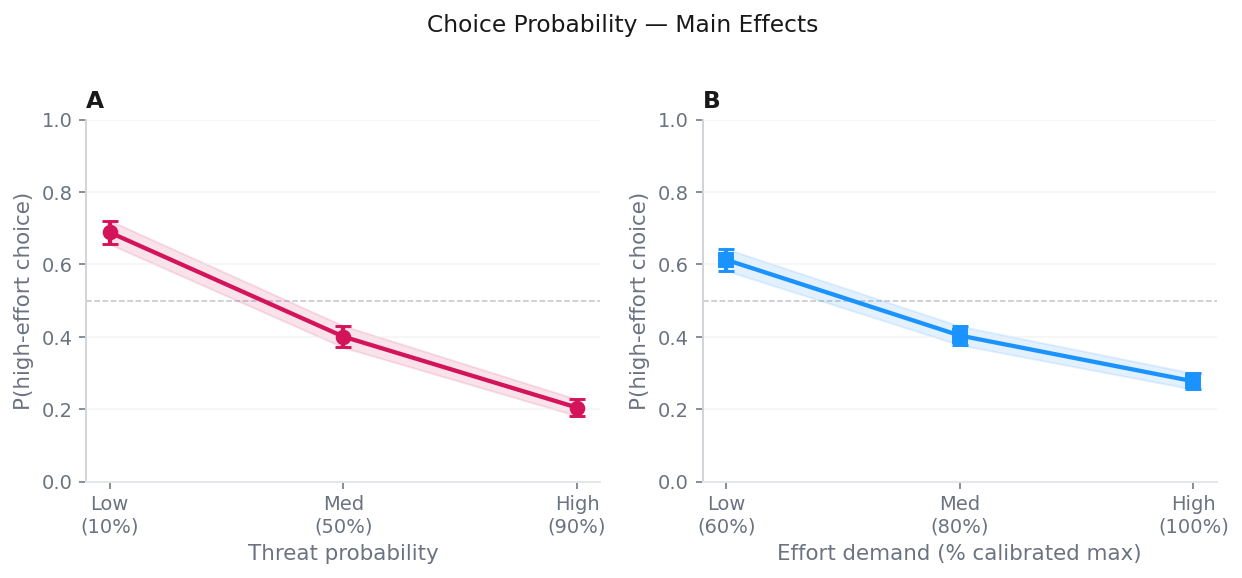

Saved.


In [4]:
# ── Figure 1: Main effects — threat and effort ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Panel A: P(high-effort) by Threat
ax = axes[0]
xs  = [0.1, 0.5, 0.9]
ys  = by_threat.sort_values('threat')['mean'].values
cis = by_threat.sort_values('threat')['ci95'].values

ax.axhline(0.5, color=Colors.INK, lw=0.8, ls='--', alpha=0.4)
ax.errorbar(xs, ys, yerr=cis, fmt='o-', color=Colors.RUBY1, lw=2.2,
            ms=7, capsize=4, capthick=1.5, zorder=3)
ax.fill_between(xs, ys - cis, ys + cis, color=Colors.RUBY1, alpha=0.12)
ax.set_xticks(xs)
ax.set_xticklabels(['Low\n(10%)', 'Med\n(50%)', 'High\n(90%)'], fontsize=10)
ax.set_xlabel('Threat probability', fontsize=11, color=Colors.INK)
ax.set_title('A', fontsize=12, fontweight='bold', loc='left', color=Colors.DARK_GREY)
style_axis(ax, ylabel='P(high-effort choice)', ylim=(0, 1.0))
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Panel B: P(high-effort) by Effort level
ax = axes[1]
xs2  = [0.6, 0.8, 1.0]
ys2  = by_effort.sort_values('effort_H')['mean'].values
cis2 = by_effort.sort_values('effort_H')['ci95'].values

ax.axhline(0.5, color=Colors.INK, lw=0.8, ls='--', alpha=0.4)
ax.errorbar(xs2, ys2, yerr=cis2, fmt='s-', color=Colors.CERULEAN2, lw=2.2,
            ms=7, capsize=4, capthick=1.5, zorder=3)
ax.fill_between(xs2, ys2 - cis2, ys2 + cis2, color=Colors.CERULEAN2, alpha=0.12)
ax.set_xticks(xs2)
ax.set_xticklabels(['Low\n(60%)', 'Med\n(80%)', 'High\n(100%)'], fontsize=10)
ax.set_xlabel('Effort demand (% calibrated max)', fontsize=11, color=Colors.INK)
ax.set_title('B', fontsize=12, fontweight='bold', loc='left', color=Colors.DARK_GREY)
style_axis(ax, ylabel='P(high-effort choice)', ylim=(0, 1.0))
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig.suptitle('Choice Probability — Main Effects', fontsize=12, color=Colors.DARK_GREY, y=1.02)
fig.tight_layout()
fig.savefig(FIGS_DIR / 'fig1_choice_main_effects.pdf', bbox_inches='tight', dpi=140)
fig.savefig(FIGS_DIR / 'fig1_choice_main_effects.png', bbox_inches='tight', dpi=140)
plt.show()
print('Saved.')


---
## Figure 2 — Effort × Threat Interaction

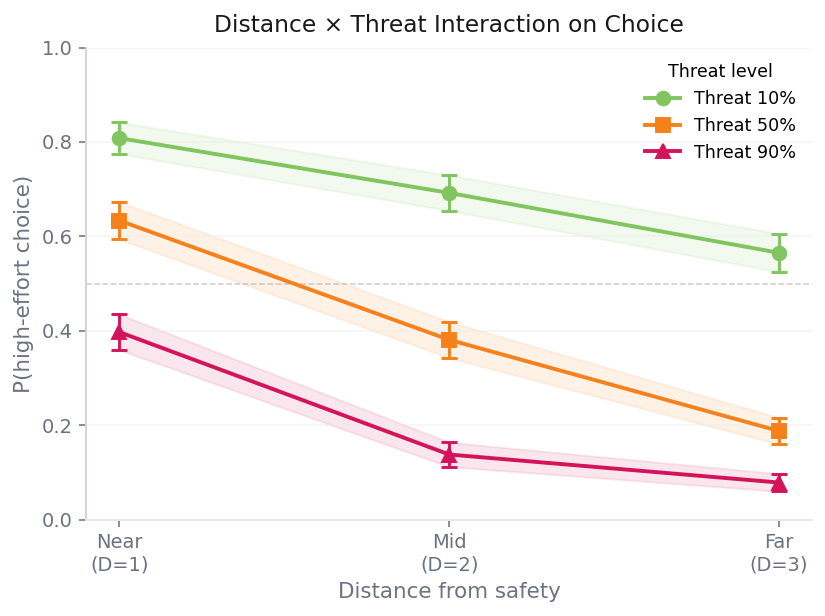

Saved.


In [5]:
# ── Figure 2: Distance × Threat interaction ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 4.5))

threat_levels = sorted(beh['threat'].unique())
col_map  = {0.1: Colors.PALETTE['mantlis_1'],
            0.5: Colors.PALETTE['persimmon_2'],
            0.9: Colors.RUBY1}
markers  = ['o', 's', '^']
dist_xs  = [0, 1, 2]
dist_labels = ['Near\n(D=1)', 'Mid\n(D=2)', 'Far\n(D=3)']

for i, thr in enumerate(threat_levels):
    sub = by_thr_dist[by_thr_dist['threat'] == thr].sort_values('distance_H')
    ys  = sub['mean'].values
    ci  = sub['ci95'].values
    col = col_map[thr]
    ax.plot(dist_xs, ys, f'{markers[i]}-', color=col, lw=2,
            ms=7, label=f'Threat {int(thr*100)}%', zorder=3)
    ax.errorbar(dist_xs, ys, yerr=ci, fmt='none', color=col,
                capsize=4, capthick=1.5, lw=1.5, zorder=4)
    ax.fill_between(dist_xs, ys - ci, ys + ci, color=col, alpha=0.10)

ax.axhline(0.5, color=Colors.INK, lw=0.8, ls='--', alpha=0.35)
ax.set_xticks(dist_xs)
ax.set_xticklabels(dist_labels, fontsize=10)
ax.set_xlabel('Distance from safety', fontsize=11, color=Colors.INK)
ax.legend(title='Threat level', fontsize=9, title_fontsize=9, frameon=False, loc='upper right')
style_axis(ax, ylabel='P(high-effort choice)', ylim=(0, 1.0))
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_title('Distance × Threat Interaction on Choice', fontsize=12, color=Colors.DARK_GREY, pad=8)

fig.tight_layout()
fig.savefig(FIGS_DIR / 'fig2_choice_interaction.pdf', bbox_inches='tight', dpi=140)
fig.savefig(FIGS_DIR / 'fig2_choice_interaction.png', bbox_inches='tight', dpi=140)
plt.show()
print('Saved.')


---
## Figure 3 — Capture Rates

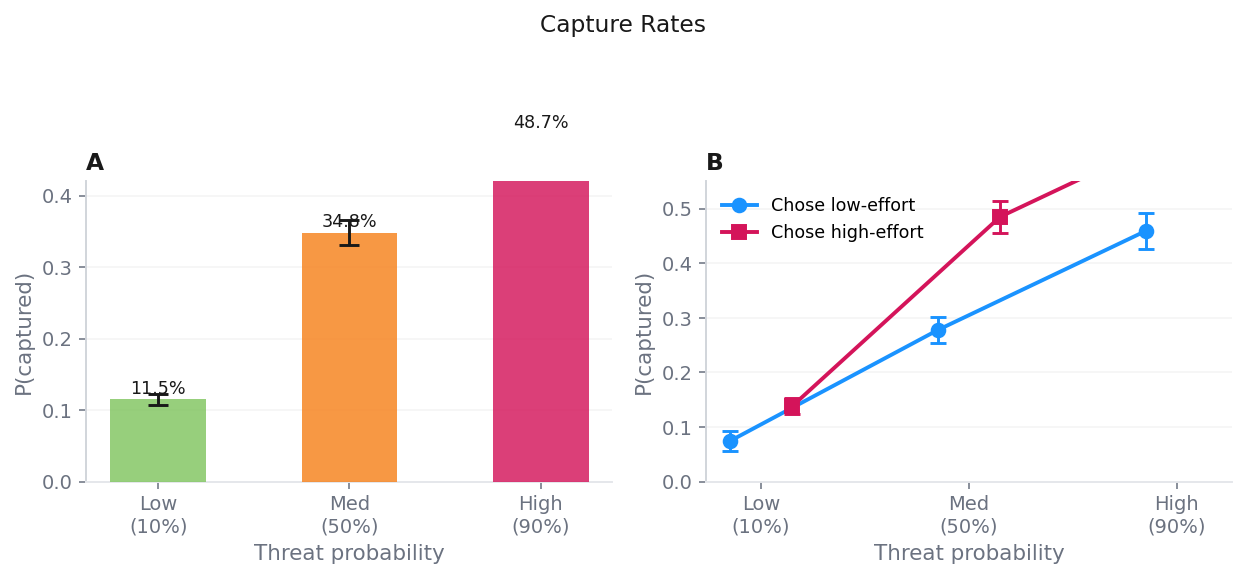

Overall: 4178/13185 = 0.317

Capture rate by threat:
         sum  count      mean
threat                       
0.1      505   4395  0.114903
0.5     1531   4395  0.348350
0.9     2142   4395  0.487372


In [6]:
# ── Figure 3: Capture rates by threat and by choice ─────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Panel A: Capture rate by threat level
ax = axes[0]
t_xs  = [0, 1, 2]
t_ys  = cap_by_threat.sort_values('threat')['mean'].values
t_cis = cap_by_threat.sort_values('threat')['ci95'].values
bar_cols = [Colors.PALETTE['mantlis_1'], Colors.PALETTE['persimmon_2'], Colors.RUBY1]

ax.bar(t_xs, t_ys, color=bar_cols, width=0.5, alpha=0.82, zorder=3)
ax.errorbar(t_xs, t_ys, yerr=t_cis, fmt='none',
            color=Colors.DARK_GREY, capsize=5, capthick=1.5, lw=1.5, zorder=4)
for x, y in zip(t_xs, t_ys):
    ax.text(x, y + 0.008, f'{y:.1%}', ha='center', fontsize=9, color=Colors.DARK_GREY)
ax.set_xticks(t_xs)
ax.set_xticklabels(['Low\n(10%)', 'Med\n(50%)', 'High\n(90%)'], fontsize=10)
ax.set_xlabel('Threat probability', fontsize=11, color=Colors.INK)
ax.set_title('A', fontsize=12, fontweight='bold', loc='left', color=Colors.DARK_GREY)
style_axis(ax, ylabel='P(captured)', ylim=(0, 0.42))
ax.set_yticks([0, 0.10, 0.20, 0.30, 0.40])

# Panel B: Capture rate by choice × threat
ax = axes[1]
cap_ct = beh.groupby(['subj', 'choice', 'threat'])['outcome'].mean().reset_index()
cct_grp = cap_ct.groupby(['choice', 'threat'])['outcome'].agg(
    mean='mean', sem='sem').reset_index()
cct_grp['ci95'] = cct_grp['sem'] * 1.96

offsets = {0: -0.15, 1: 0.15}
choice_labels = {0: 'Chose low-effort', 1: 'Chose high-effort'}
choice_cols   = {0: Colors.CERULEAN2, 1: Colors.RUBY1}
choice_marks  = {0: 'o', 1: 's'}

for ch in [0, 1]:
    sub = cct_grp[cct_grp['choice'] == ch].sort_values('threat')
    xs  = [i + offsets[ch] for i in range(3)]
    ys  = sub['mean'].values
    ci  = sub['ci95'].values
    ax.plot(xs, ys, f'{choice_marks[ch]}-', color=choice_cols[ch],
            lw=2, ms=7, label=choice_labels[ch], zorder=3)
    ax.errorbar(xs, ys, yerr=ci, fmt='none', color=choice_cols[ch],
                capsize=4, capthick=1.5, lw=1.5, zorder=4)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Low\n(10%)', 'Med\n(50%)', 'High\n(90%)'], fontsize=10)
ax.set_xlabel('Threat probability', fontsize=11, color=Colors.INK)
ax.legend(fontsize=9, frameon=False, loc='upper left')
ax.set_title('B', fontsize=12, fontweight='bold', loc='left', color=Colors.DARK_GREY)
style_axis(ax, ylabel='P(captured)', ylim=(0, 0.55))
ax.set_yticks([0, 0.10, 0.20, 0.30, 0.40, 0.50])

fig.suptitle('Capture Rates', fontsize=12, color=Colors.DARK_GREY, y=1.02)
fig.tight_layout()
fig.savefig(FIGS_DIR / 'fig3_capture_rates.pdf', bbox_inches='tight', dpi=140)
fig.savefig(FIGS_DIR / 'fig3_capture_rates.png', bbox_inches='tight', dpi=140)
plt.show()

print(f'Overall: {n_captures:.0f}/{N_trial} = {cap_rate_overall:.3f}')
print('\nCapture rate by threat:')
print(beh.groupby('threat')['outcome'].agg(['sum', 'count', 'mean']))


---
## Figure 4 — Subject-Level Distributions

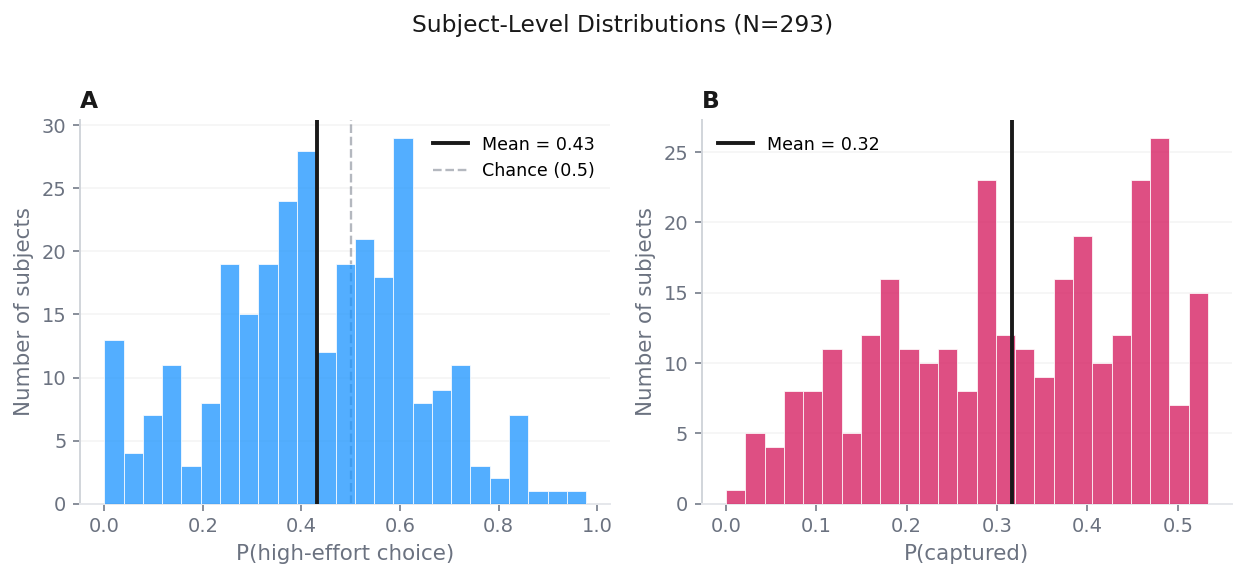

P(high-effort): M=0.431, SD=0.203, range [0.000, 0.978]
P(captured):    M=0.317, SD=0.144, range [0.000, 0.533]


In [7]:
# ── Figure 4: Subject-level distributions ───────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Panel A: Distribution of P(high-effort) across subjects
ax = axes[0]
vals = subj_summary['p_high'].values
ax.hist(vals, bins=25, color=Colors.CERULEAN2, alpha=0.75, edgecolor='white', lw=0.5, zorder=3)
ax.axvline(vals.mean(), color=Colors.DARK_GREY, lw=2, zorder=4,
           label=f'Mean = {vals.mean():.2f}')
ax.axvline(0.5, color=Colors.INK, lw=1.2, ls='--', alpha=0.5, label='Chance (0.5)')
ax.set_xlabel('P(high-effort choice)', fontsize=11, color=Colors.INK)
ax.set_title('A', fontsize=12, fontweight='bold', loc='left', color=Colors.DARK_GREY)
ax.legend(fontsize=9, frameon=False)
style_axis(ax, ylabel='Number of subjects')

# Panel B: Distribution of capture rates across subjects
ax = axes[1]
cap_vals = subj_summary['p_cap'].values
ax.hist(cap_vals, bins=25, color=Colors.RUBY1, alpha=0.75, edgecolor='white', lw=0.5, zorder=3)
ax.axvline(cap_vals.mean(), color=Colors.DARK_GREY, lw=2, zorder=4,
           label=f'Mean = {cap_vals.mean():.2f}')
ax.set_xlabel('P(captured)', fontsize=11, color=Colors.INK)
ax.set_title('B', fontsize=12, fontweight='bold', loc='left', color=Colors.DARK_GREY)
ax.legend(fontsize=9, frameon=False)
style_axis(ax, ylabel='Number of subjects')

fig.suptitle('Subject-Level Distributions (N=293)', fontsize=12, color=Colors.DARK_GREY, y=1.02)
fig.tight_layout()
fig.savefig(FIGS_DIR / 'fig4_subject_distributions.pdf', bbox_inches='tight', dpi=140)
fig.savefig(FIGS_DIR / 'fig4_subject_distributions.png', bbox_inches='tight', dpi=140)
plt.show()

print(f'P(high-effort): M={vals.mean():.3f}, SD={vals.std():.3f}, '
      f'range [{vals.min():.3f}, {vals.max():.3f}]')
print(f'P(captured):    M={cap_vals.mean():.3f}, SD={cap_vals.std():.3f}, '
      f'range [{cap_vals.min():.3f}, {cap_vals.max():.3f}]')


---
## Figure 5 — Combined Publication Figure (2×2)

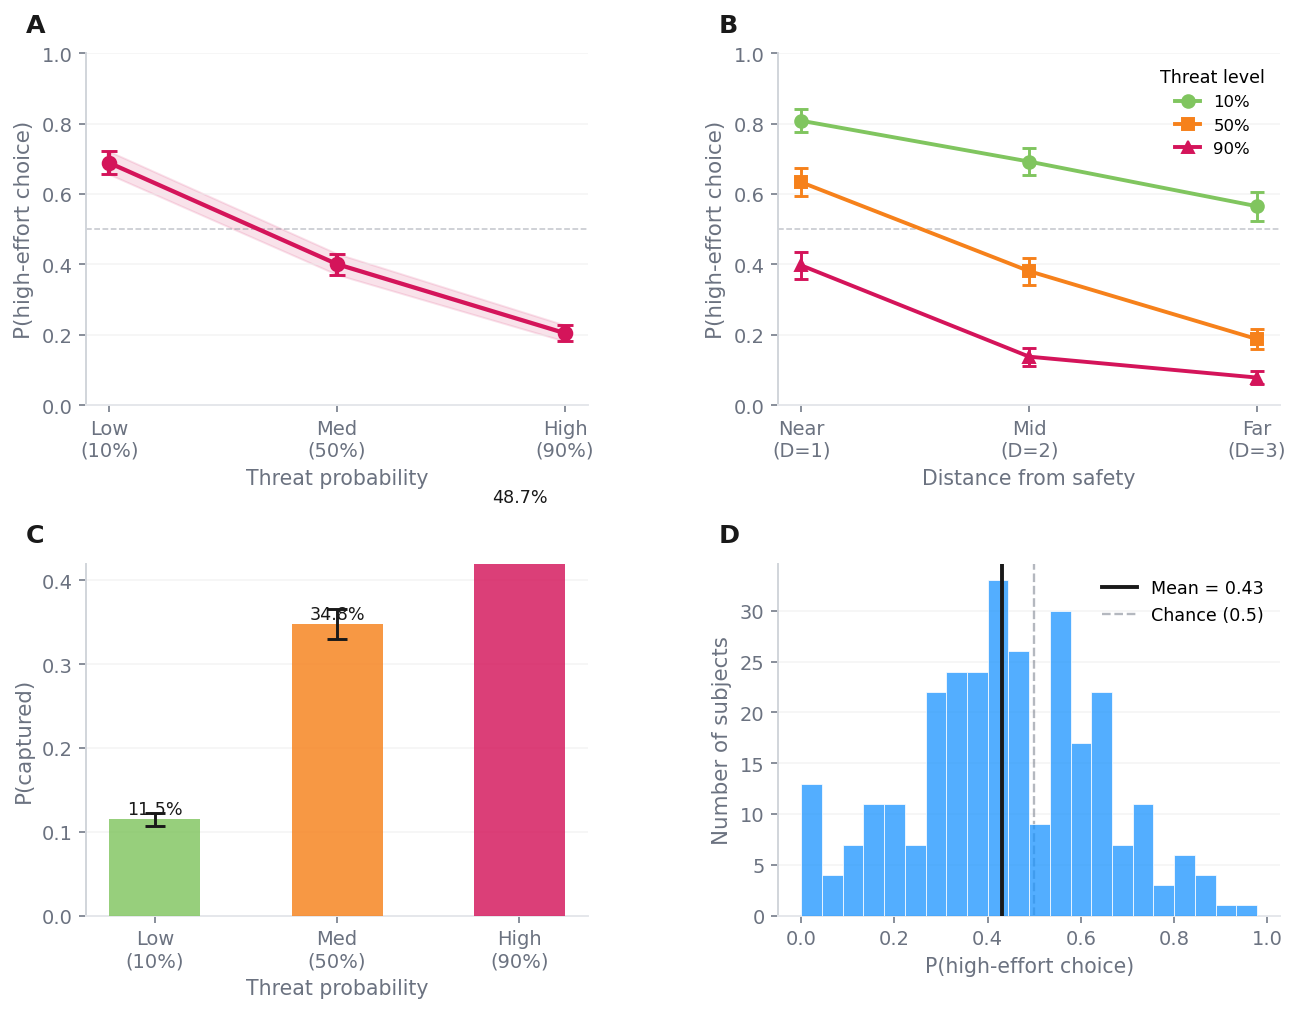

Combined figure saved.


In [8]:
# ── Figure 5: Combined 2×2 publication figure ────────────────────────────────────
# A: Choice by threat  |  B: Distance × threat interaction
# C: Capture by threat |  D: Subject distribution of P(high-effort)

fig = plt.figure(figsize=(11, 8))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38)

# ── Panel A: P(high-effort) by threat ─────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
xs  = [0.1, 0.5, 0.9]
ys  = by_threat.sort_values('threat')['mean'].values
cis = by_threat.sort_values('threat')['ci95'].values
ax.axhline(0.5, color=Colors.INK, lw=0.8, ls='--', alpha=0.4)
ax.errorbar(xs, ys, yerr=cis, fmt='o-', color=Colors.RUBY1, lw=2.2,
            ms=7, capsize=4, capthick=1.5, zorder=3)
ax.fill_between(xs, ys - cis, ys + cis, color=Colors.RUBY1, alpha=0.12)
ax.set_xticks(xs)
ax.set_xticklabels(['Low\n(10%)', 'Med\n(50%)', 'High\n(90%)'], fontsize=9.5)
ax.set_xlabel('Threat probability', fontsize=10.5, color=Colors.INK)
ax.text(-0.12, 1.06, 'A', transform=ax.transAxes, fontsize=13,
        fontweight='bold', color=Colors.DARK_GREY)
style_axis(ax, ylabel='P(high-effort choice)', ylim=(0, 1.0))
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# ── Panel B: Distance × threat interaction ────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
threat_levels = sorted(beh['threat'].unique())
col_map  = {0.1: Colors.PALETTE['mantlis_1'],
            0.5: Colors.PALETTE['persimmon_2'],
            0.9: Colors.RUBY1}
markers  = ['o', 's', '^']
for i, thr in enumerate(threat_levels):
    sub = by_thr_dist[by_thr_dist['threat'] == thr].sort_values('distance_H')
    ys2 = sub['mean'].values
    ci2 = sub['ci95'].values
    col = col_map[thr]
    ax.plot([0, 1, 2], ys2, f'{markers[i]}-', color=col, lw=2,
            ms=6.5, label=f'{int(thr*100)}%', zorder=3)
    ax.errorbar([0, 1, 2], ys2, yerr=ci2, fmt='none', color=col,
                capsize=3.5, capthick=1.5, lw=1.5, zorder=4)
ax.axhline(0.5, color=Colors.INK, lw=0.8, ls='--', alpha=0.4)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Near\n(D=1)', 'Mid\n(D=2)', 'Far\n(D=3)'], fontsize=9.5)
ax.set_xlabel('Distance from safety', fontsize=10.5, color=Colors.INK)
ax.legend(title='Threat level', fontsize=8.5, title_fontsize=9,
          frameon=False, loc='upper right', handlelength=1.5)
ax.text(-0.12, 1.06, 'B', transform=ax.transAxes, fontsize=13,
        fontweight='bold', color=Colors.DARK_GREY)
style_axis(ax, ylabel='P(high-effort choice)', ylim=(0, 1.0))
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# ── Panel C: Capture rate by threat ───────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
t_xs  = [0, 1, 2]
t_ys  = cap_by_threat.sort_values('threat')['mean'].values
t_cis = cap_by_threat.sort_values('threat')['ci95'].values
bar_cols = [Colors.PALETTE['mantlis_1'], Colors.PALETTE['persimmon_2'], Colors.RUBY1]
ax.bar(t_xs, t_ys, color=bar_cols, width=0.5, alpha=0.82, zorder=3)
ax.errorbar(t_xs, t_ys, yerr=t_cis, fmt='none',
            color=Colors.DARK_GREY, capsize=5, capthick=1.5, lw=1.5, zorder=4)
for x, y in zip(t_xs, t_ys):
    ax.text(x, y + 0.006, f'{y:.1%}', ha='center', fontsize=9, color=Colors.DARK_GREY)
ax.set_xticks(t_xs)
ax.set_xticklabels(['Low\n(10%)', 'Med\n(50%)', 'High\n(90%)'], fontsize=9.5)
ax.set_xlabel('Threat probability', fontsize=10.5, color=Colors.INK)
ax.text(-0.12, 1.06, 'C', transform=ax.transAxes, fontsize=13,
        fontweight='bold', color=Colors.DARK_GREY)
style_axis(ax, ylabel='P(captured)', ylim=(0, 0.42))
ax.set_yticks([0, 0.10, 0.20, 0.30, 0.40])

# ── Panel D: Subject-level P(high-effort) distribution ────────────────────────
ax = fig.add_subplot(gs[1, 1])
vals = subj_summary['p_high'].values
ax.hist(vals, bins=22, color=Colors.CERULEAN2, alpha=0.75, edgecolor='white', lw=0.5, zorder=3)
ax.axvline(vals.mean(), color=Colors.DARK_GREY, lw=2, zorder=4,
           label=f'Mean = {vals.mean():.2f}')
ax.axvline(0.5, color=Colors.INK, lw=1.2, ls='--', alpha=0.5, label='Chance (0.5)')
ax.set_xlabel('P(high-effort choice)', fontsize=10.5, color=Colors.INK)
ax.legend(fontsize=9, frameon=False)
ax.text(-0.12, 1.06, 'D', transform=ax.transAxes, fontsize=13,
        fontweight='bold', color=Colors.DARK_GREY)
style_axis(ax, ylabel='Number of subjects')

fig.savefig(FIGS_DIR / 'fig5_combined_behavior.pdf', bbox_inches='tight', dpi=140)
fig.savefig(FIGS_DIR / 'fig5_combined_behavior.png', bbox_inches='tight', dpi=140)
plt.show()
print('Combined figure saved.')


---
## Summary Statistics

In [9]:
# ── Summary Table ──────────────────────────────────────────────────────────────

print('=' * 60)
print('BEHAVIORAL SUMMARY — Exploratory Sample (N=293)')
print('=' * 60)
print(f'Trials: {N_trial} ({N_trial/N_subj:.1f} per subject)')
print(f'Subjects: {N_subj}')

print('\n--- Choice ---')
overall_choice = beh['choice'].mean()
print(f'Overall P(high-effort): {overall_choice:.3f} '
      f'(SD {beh.groupby("subj")["choice"].mean().std():.3f})')

print('\nBy threat:')
for _, row in by_threat.sort_values('threat').iterrows():
    print(f'  T={row["threat"]}: M={row["mean"]:.3f} +/- {row["ci95"]:.3f} (95% CI)')

print('\nBy effort level:')
for _, row in by_effort.sort_values('effort_H').iterrows():
    print(f'  E={row["effort_H"]}: M={row["mean"]:.3f} +/- {row["ci95"]:.3f} (95% CI)')

print('\n--- Captures ---')
print(f'Overall: {n_captures:.0f}/{N_trial} = {cap_rate_overall:.3f}')
print('\nBy threat:')
print(beh.groupby('threat')['outcome'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'n_cap', 'count': 'n_trial', 'mean': 'rate'}))

print('\n--- Subject-level variability ---')
subj_props = beh.groupby('subj')['choice'].mean()
print(f'P(high-effort) across subjects: '
      f'min={subj_props.min():.3f}, max={subj_props.max():.3f}')
print(f'  IQR=[{subj_props.quantile(0.25):.3f}, {subj_props.quantile(0.75):.3f}]')

subj_caps = beh.groupby('subj')['outcome'].mean()
print(f'P(captured) across subjects: '
      f'min={subj_caps.min():.3f}, max={subj_caps.max():.3f}')
print(f'  IQR=[{subj_caps.quantile(0.25):.3f}, {subj_caps.quantile(0.75):.3f}]')


BEHAVIORAL SUMMARY — Exploratory Sample (N=293)
Trials: 13185 (45.0 per subject)
Subjects: 293

--- Choice ---
Overall P(high-effort): 0.431 (SD 0.203)

By threat:
  T=0.1: M=0.689 +/- 0.033 (95% CI)
  T=0.5: M=0.401 +/- 0.030 (95% CI)
  T=0.9: M=0.205 +/- 0.023 (95% CI)

By effort level:
  E=0.6: M=0.613 +/- 0.030 (95% CI)
  E=0.8: M=0.404 +/- 0.026 (95% CI)
  E=1.0: M=0.277 +/- 0.022 (95% CI)

--- Captures ---
Overall: 4178/13185 = 0.317

By threat:
        n_cap  n_trial      rate
threat                          
0.1       505     4395  0.114903
0.5      1531     4395  0.348350
0.9      2142     4395  0.487372

--- Subject-level variability ---
P(high-effort) across subjects: min=0.000, max=0.978
  IQR=[0.289, 0.578]
P(captured) across subjects: min=0.000, max=0.533
  IQR=[0.200, 0.444]
